# Calculate Sternberg model tuning -- to load, and to stimulus identity

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-04-27 13:21:53.795426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 13:21:53.804183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 13:21:53.813264: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-27 13:21:53.815943: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 13:21:53.823302: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# the two models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

8
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_140925', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


In [4]:
# find folder names within model directory

perfs = []
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    load1_idx = np.where(trial_labels[:,0] == 1)[0]
    load3_idx = np.where(trial_labels[:,0] == 3)[0]
    perfs.append([np.mean(trial_perfs[load1_idx]), np.mean(trial_perfs[load3_idx])])
    print(f'Model {model_name}, performance: {perfs[i]}')


Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205, performance: [0.8541666666666666, 0.6006944444444444]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533, performance: [0.7083333333333334, 0.8055555555555556]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940, performance: [0.8333333333333334, 0.6423611111111112]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957, performance: [0.75, 0.6909722222222222]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713, performance: [0.75, 0.7048611111111112]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959, performance: [0.75, 0.6666666666666666]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_17_140925, performance: [0.7083333333333334, 0.6145833333333334]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058, performance: [0.7291666666666666, 0.6354166666666666]


## Load-selectivity

### single model

In [5]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/settings_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/neural_dict_delay200_balance_match.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/settings_dict_delay200_balance_match.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/neural_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/bhv_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/bhv_dict_delay200_balance_match.pkl']


In [10]:
# neural data
importlib.reload(ld)
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, 
                                         other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
print(rates_data.shape)

(200, 1000, 450)


In [12]:
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                      other_labels= "balance_match",
                                      all_models_dir=all_models_dir)
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 200,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}

In [11]:
# behavioral data
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                         other_labels= "balance_match",
                                         all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

# trial_labels is (load, match/mismatch)

(200, 6) (200,) (200, 450)


(0.0, 600.0)

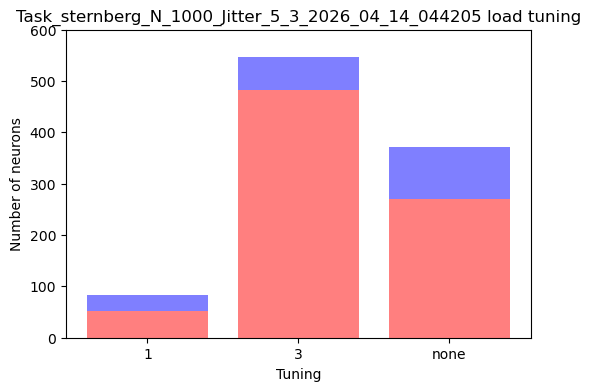

In [18]:
importlib.reload(rn)

tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                             rates_data = rates_data,
                             other_labels= "balance_match",
                             all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

fig, ax = plt.subplots(figsize=(6, 4))
rn.plot_load_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} load tuning', ax=ax)
ax.set_ylim(0, 600)


(0.0, 600.0)

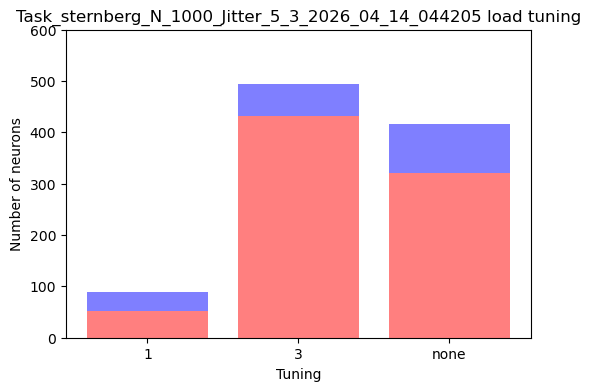

In [19]:
importlib.reload(rn)

tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                             other_labels= "balance_stim",
                             all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

fig, ax = plt.subplots(figsize=(6, 4))
rn.plot_load_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} load tuning', ax=ax)
ax.set_ylim(0, 600)


### all models

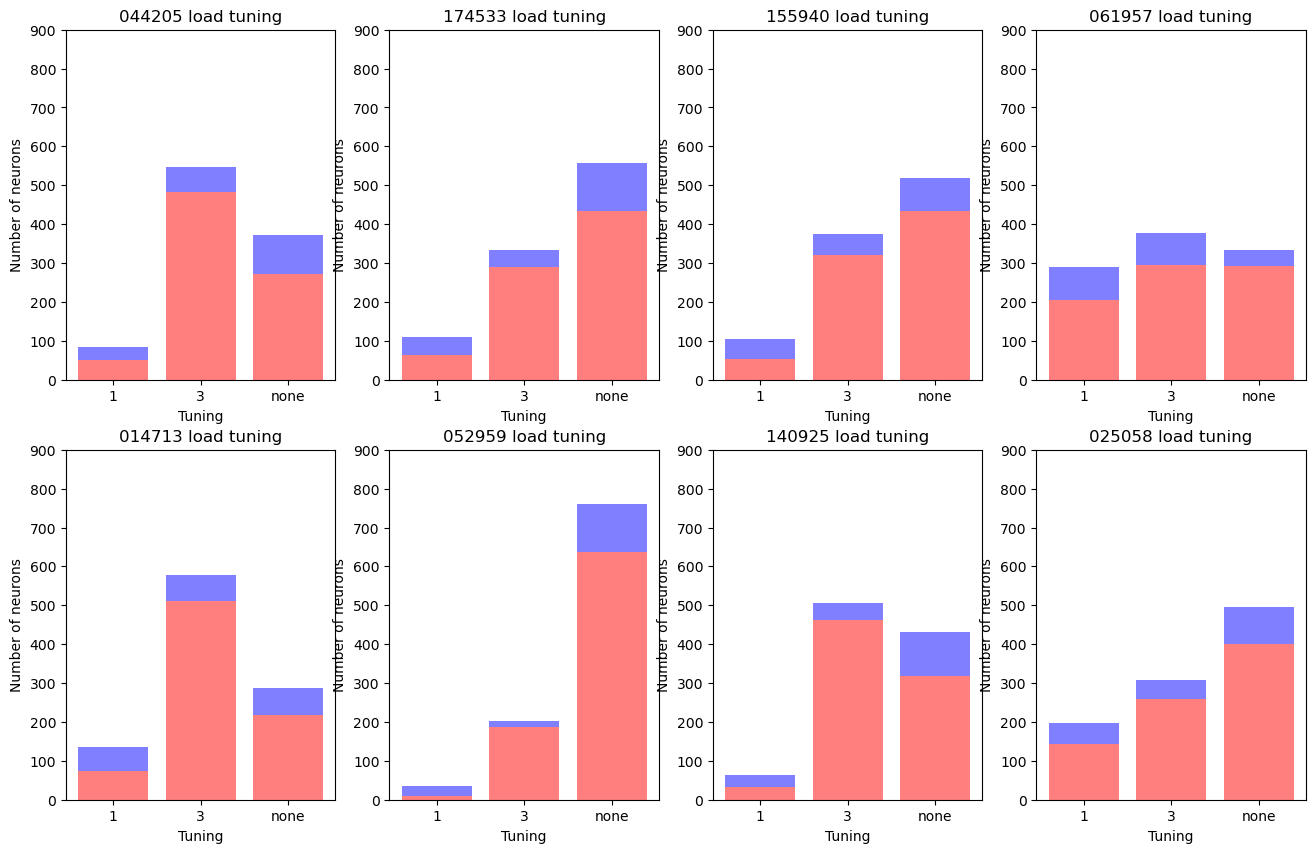

In [22]:
importlib.reload(rn)

fig, axs = plt.subplots(2, 4, figsize=(16,10))
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    rn.plot_load_tuning(tuning, exc_ind=exc_ind, title=f'{model_name[-6:]} load tuning', ax=axs[i])
    axs[i].set_ylim([0, 900])

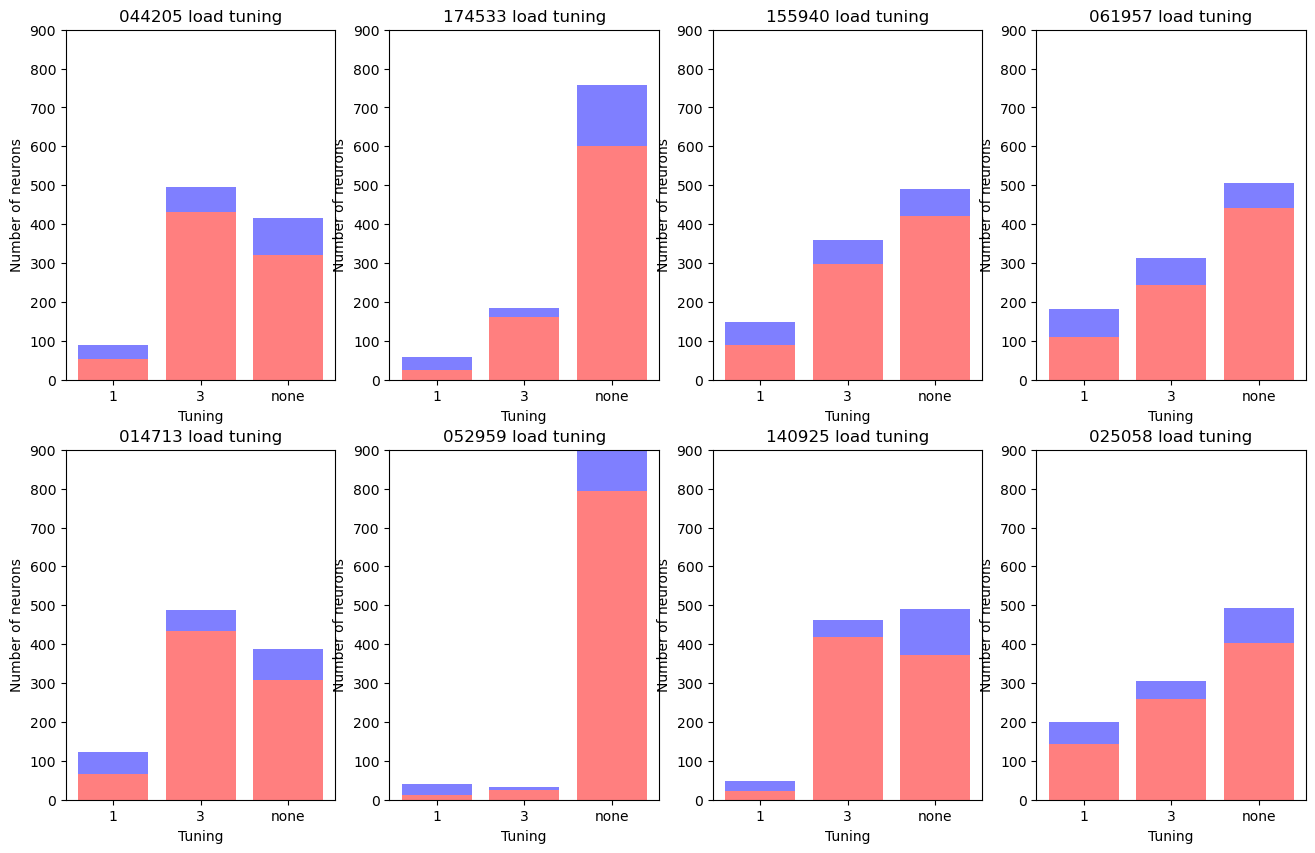

In [24]:
importlib.reload(rn)

fig, axs = plt.subplots(2, 4, figsize=(16,10))
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    rn.plot_load_tuning(tuning, exc_ind=exc_ind, title=f'{model_name[-6:]} load tuning', ax=axs[i])
    axs[i].set_ylim([0, 900])

## Stim-selectivity

### single model

In [25]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/settings_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/neural_dict_delay200_balance_match.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/settings_dict_delay200_balance_match.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/neural_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/bhv_dict_delay200_balance_stims.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/bhv_dict_delay200_balance_match.pkl']


In [26]:
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
print(rates_data_match.shape)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
print(rates_data_stim.shape)

# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

(200, 1000, 450)
(336, 1000, 450)
(536, 1000, 450)


In [27]:
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 200,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}

In [35]:
# behavioral data
trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)

print(trial_labels_match.shape, trial_perfs_match.shape, trial_outputs_match.shape)

trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)

print(trial_labels_stim.shape, trial_perfs_stim.shape, trial_outputs_stim.shape)

trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
trial_outputs = np.concatenate((trial_outputs_match, trial_outputs_stim), axis=0)

# turn all inf into nans
trial_labels = np.nan_to_num(trial_labels, nan=np.inf)
trial_perfs = np.nan_to_num(trial_perfs, nan=np.inf)
trial_outputs = np.nan_to_num(trial_outputs, nan=np.inf)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

# trial_labels is (load, match/mismatch)

(200, 6) (200,) (200, 450)
(336, 6) (336,) (336, 450)
(536, 6) (536,) (536, 450)


(112, 4)
536


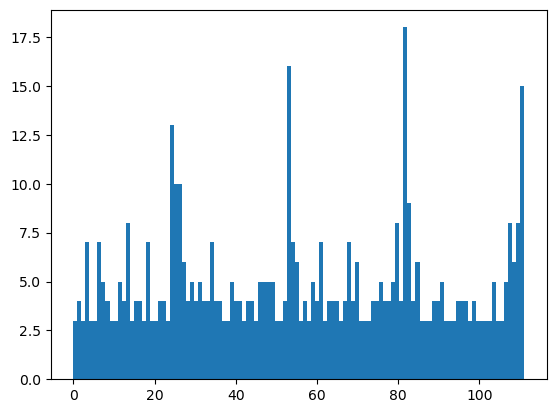

In [36]:
stim_ids = trial_labels[:,2:]
stim_ids = np.nan_to_num(stim_ids, nan=np.inf)
trial_types, trial_idxs = np.unique(stim_ids, axis=0, return_inverse=True, equal_nan=True)
print(trial_types.shape)
print(len(trial_labels))
_ = plt.hist(trial_idxs, bins=112)

In [16]:
trial_types, trial_idxs = np.unique(trial_labels[:,:2], axis=0, return_inverse=True)
print(trial_types)
print(trial_types.shape)

[[1. 0.]
 [1. 1.]
 [3. 0.]
 [3. 1.]]
(4, 2)


[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [3. 0.]
 [3. 1.]
 [3. 2.]
 [3. 3.]]
[ 39  33  39  37 100 100 100  88]


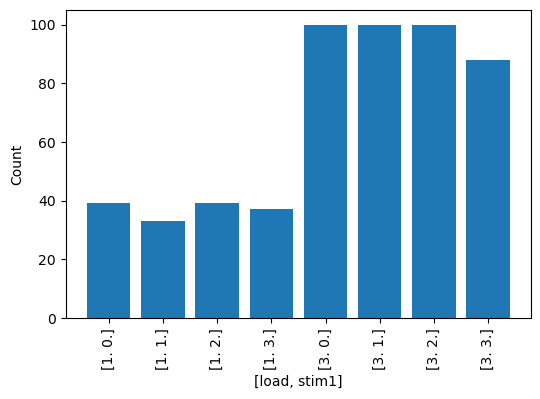

In [38]:
# stim 1 identity across loads

stim1_load = trial_labels[:,[0,2]]
trial_types, trial_idxs = np.unique(stim1_load, axis=0, return_inverse=True, equal_nan=True)
type_counts = np.bincount(trial_idxs)
print(trial_types)
print(type_counts)

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(trial_types)), type_counts)
plt.xticks(ticks=np.arange(len(trial_types)), labels=trial_types, rotation=90)
plt.xlabel('[load, stim1]')
plt.ylabel('Count')
plt.show()


Loaded behavioral variables from other_variables


Stim1 tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


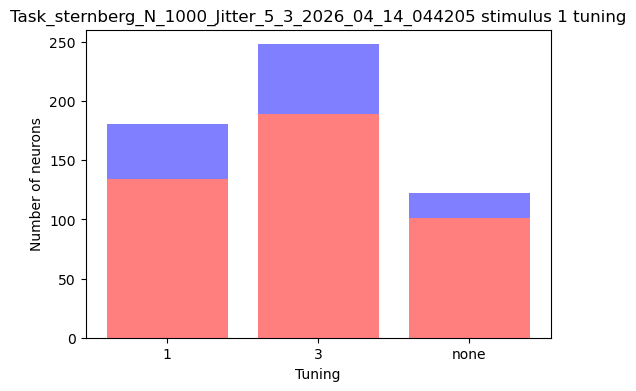

In [ ]:
importlib.reload(rn)
bhv_vars = {'trial_labels': trial_labels, 'trial_perfs': trial_perfs, 'trial_outputs': trial_outputs}
tuning = rn.calc_stim1_tuning(model_name, condn_phrase, condn_num, other_labels = "balance_match",
                     rates_data=rates_data, other_variables=bhv_vars,
                     anova_resamples=1000, pairwise_resamples=1000,
                     use_prescreen=True, prescreen_alpha=0.20,
                     show_progress=True, all_models_dir=all_models_dir)


# save tuning to the model folder as stim1_tuning.npz
save_path = os.path.join(model_dir, 'stim1_tuning.npz')
np.savez(save_path, stim1_tuning=tuning)

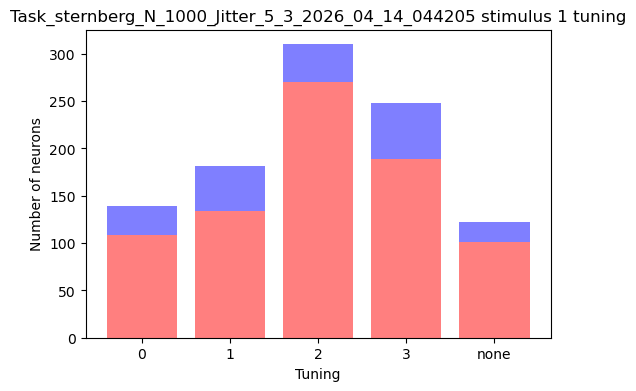

In [44]:
importlib.reload(rn)
rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} stimulus 1 tuning', ax=None)

In [ ]:
# save tuning to the model folder as stim1_tuning.npz
save_path = os.path.join(model_dir, 'stim1_tuning.npz')
np.savez(save_path, stim1_tuning=tuning)

### all models

In [47]:
os.path.join(model_dir, 'stim1_tuning.npz')

'/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/stim1_tuning.npz'

Tuning file already exists for Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205, skipping...
Loaded behavioral variables from other_variables


Stim1 tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Loaded behavioral variables from other_variables


Stim1 tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Stim1 tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Loaded behavioral variables from other_variables


Stim1 tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


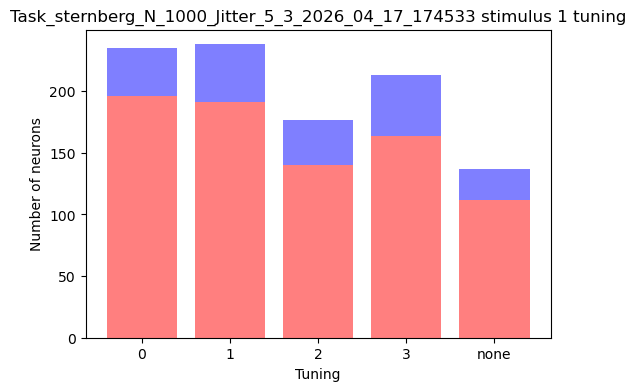

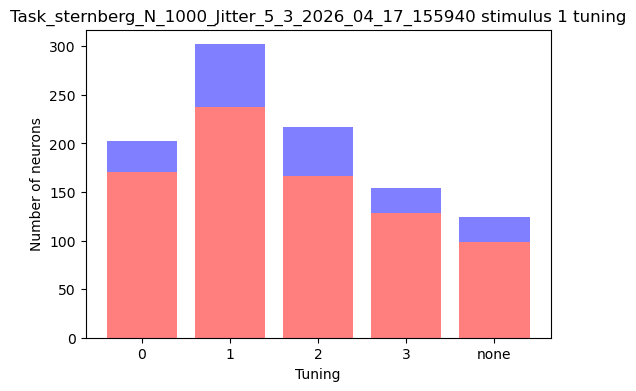

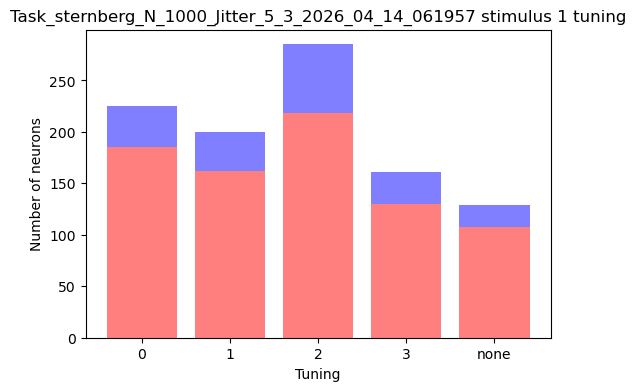

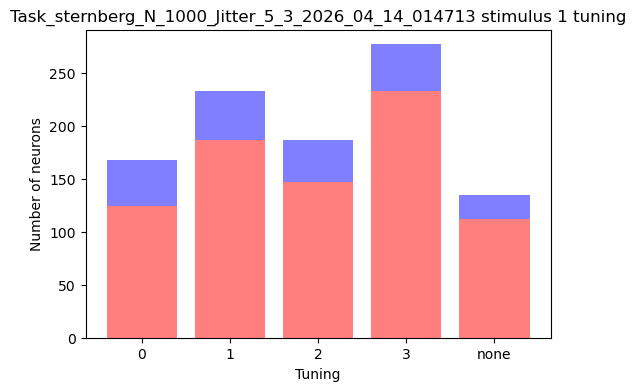

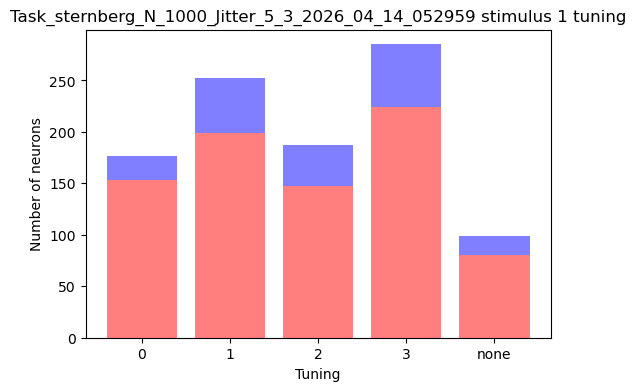

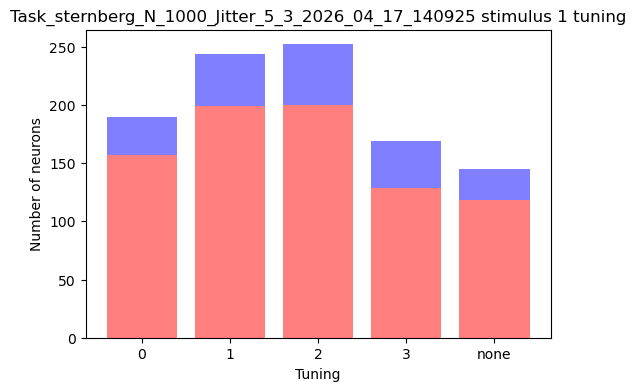

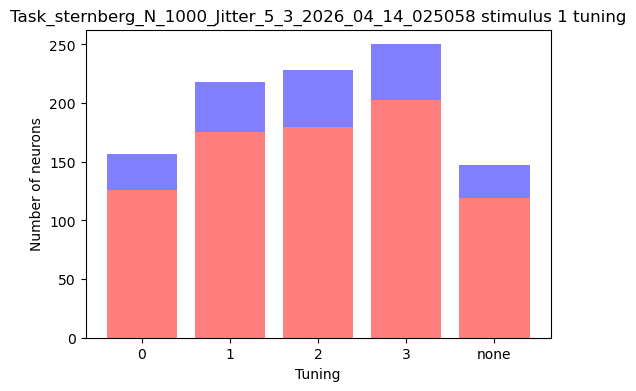

In [48]:
importlib.reload(rn)

for i, model_name in enumerate(model_names):
    
    model_dir = os.path.join(all_models_dir, model_name)
    save_path = os.path.join(model_dir, 'stim1_tuning.npz')
    if os.path.exists(save_path):
        print(f'Tuning file already exists for {model_name}, skipping...')
        continue
    
    # neural data
    _, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                                all_models_dir = all_models_dir, load_LFP=False)
    _, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                                all_models_dir = all_models_dir, load_LFP=False)
    rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0) # concatenate
    
    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    # behavioral data
    trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_match",
                                                        all_models_dir=all_models_dir)
    trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_stim",
                                                        all_models_dir=all_models_dir)
    trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
    trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
    trial_outputs = np.concatenate((trial_outputs_match, trial_outputs_stim), axis=0)

    # turn all inf into nans
    trial_labels = np.nan_to_num(trial_labels, nan=np.inf)
    trial_perfs = np.nan_to_num(trial_perfs, nan=np.inf)
    trial_outputs = np.nan_to_num(trial_outputs, nan=np.inf)

    bhv_vars = {'trial_labels': trial_labels, 'trial_perfs': trial_perfs, 'trial_outputs': trial_outputs}
    tuning = rn.calc_stim1_tuning(model_name, condn_phrase, condn_num, other_labels = "balance_match",
                        rates_data=rates_data, other_variables=bhv_vars,
                        anova_resamples=1000, pairwise_resamples=1000,
                        use_prescreen=True, prescreen_alpha=0.20,
                        show_progress=True, all_models_dir=all_models_dir)

    rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} stimulus 1 tuning', ax=None)

    # save tuning to the model folder as stim1_tuning.npz
    np.savez(save_path, stim1_tuning=tuning)

### some plots

(536, 1000, 450)


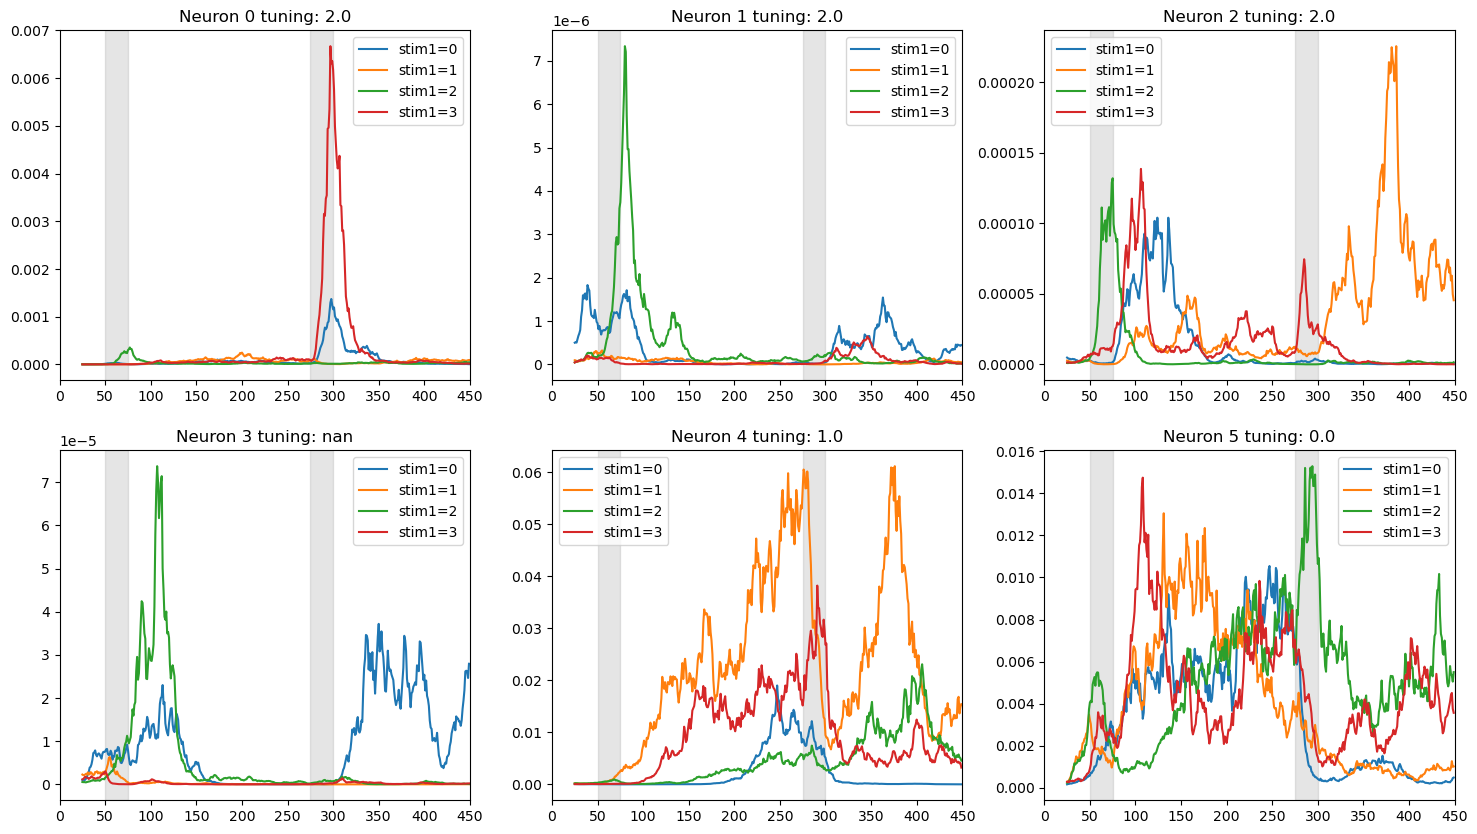

In [ ]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot a single trial

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning.npz'))['stim1_tuning']
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idx = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0][0]
        trial_rate = rates_data[trial_idx, neuron_idx, :]
        trial_rate[:25] = np.nan  # mask out the first 25 time bins to remove noise
        ax.plot(trial_rate, label=f'stim1={stim1_identity}')
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_665906/4120096948.py:44: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_665906/4120096948.py:45: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


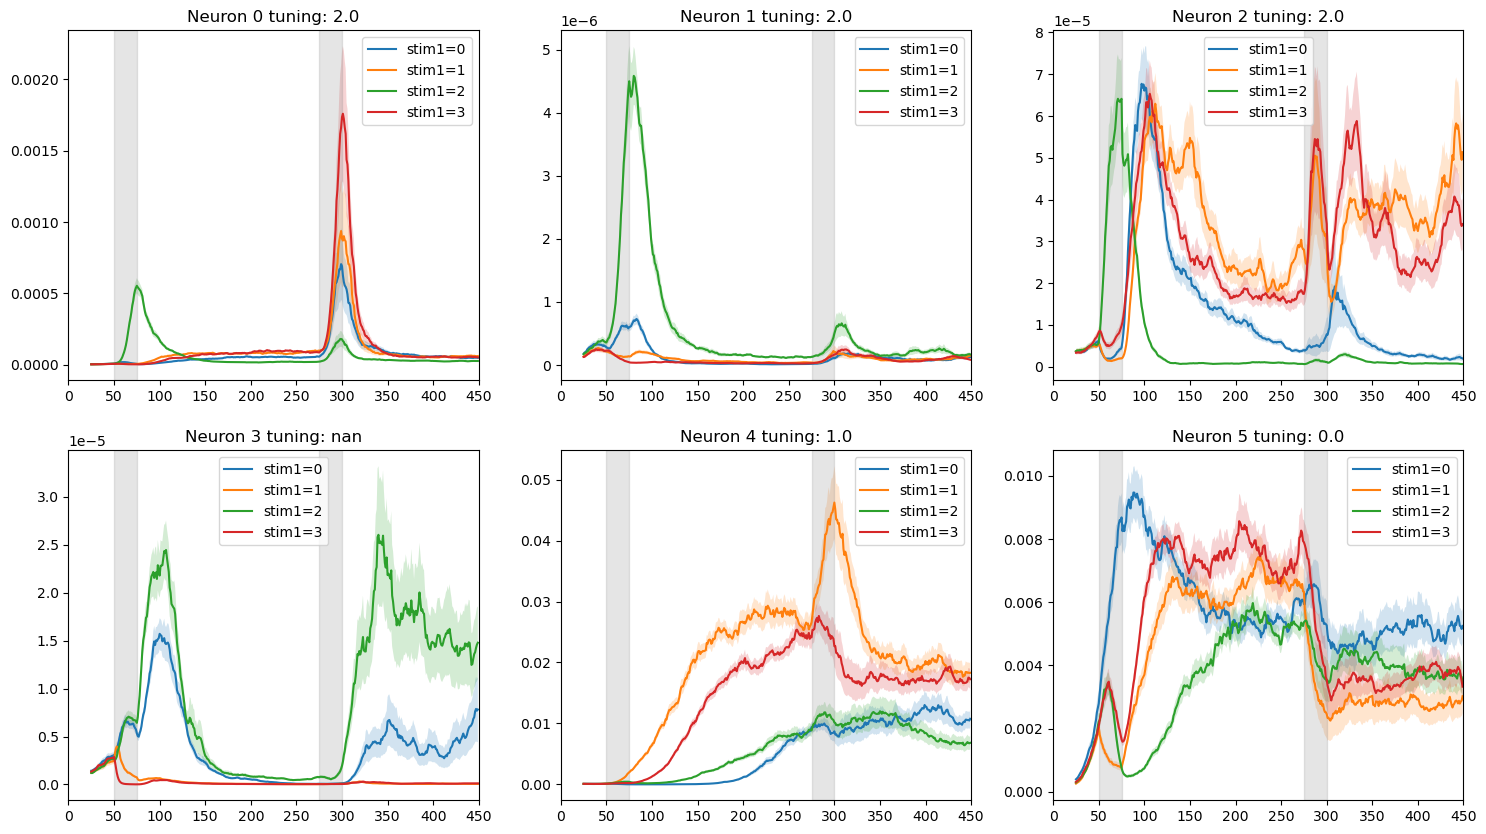

In [37]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning.npz'))['stim1_tuning']
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={stim1_identity}')
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_665906/2724458527.py:51: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_665906/2724458527.py:52: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


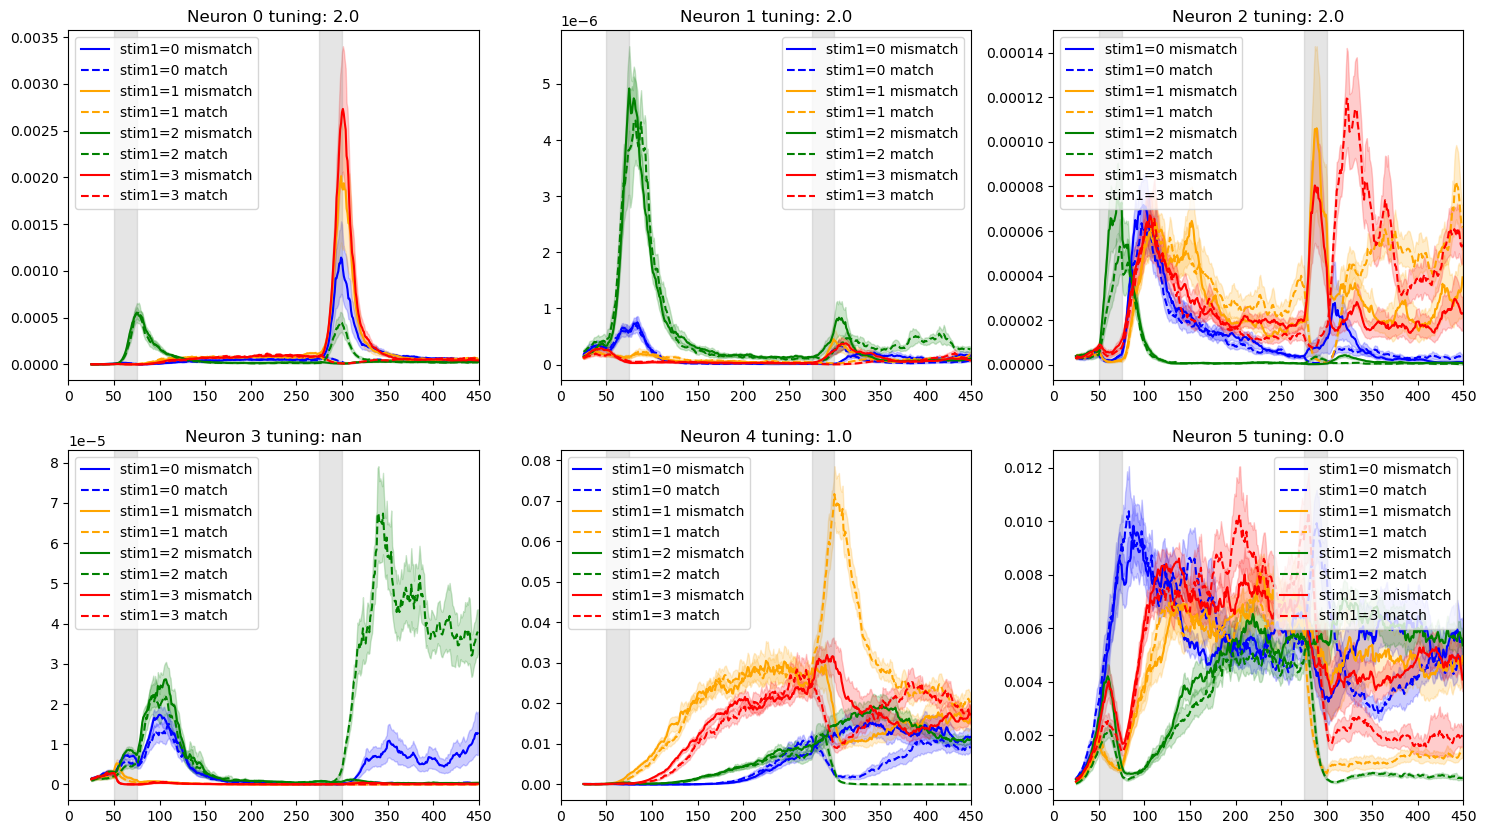

In [47]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning.npz'))['stim1_tuning']
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} tuning: {neuron_tuning}')
    ax.legend()

### run nonparametric version

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


...

Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

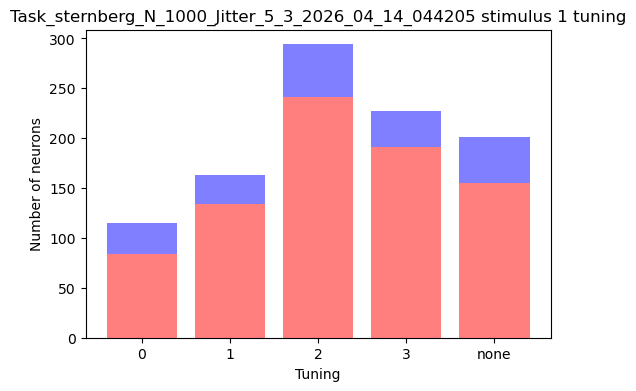

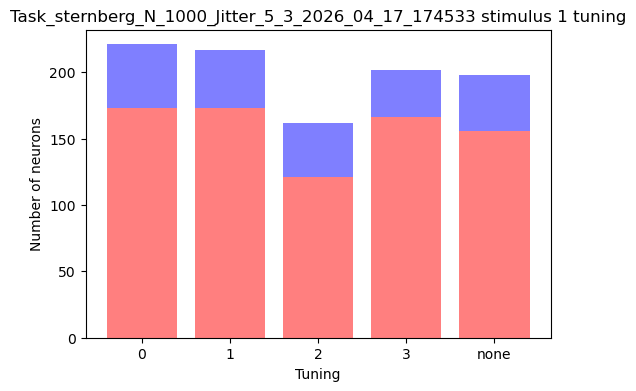

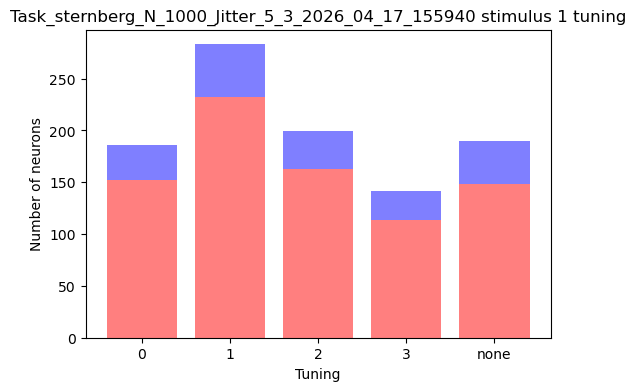

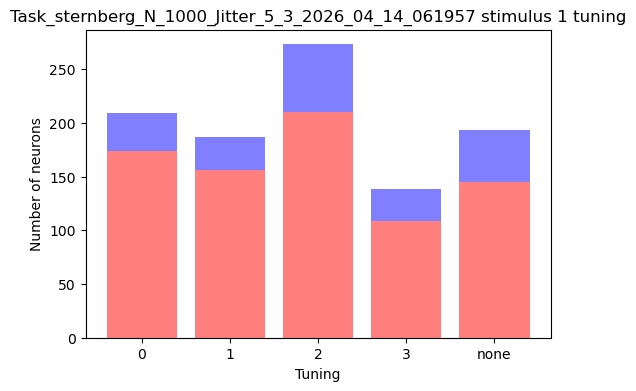

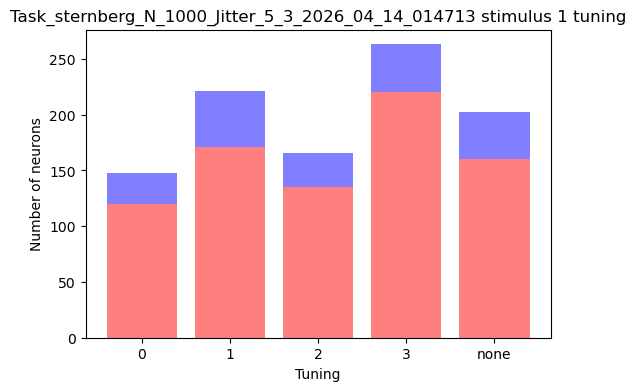

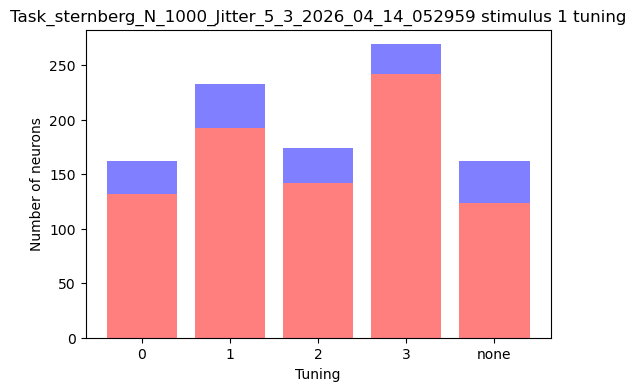

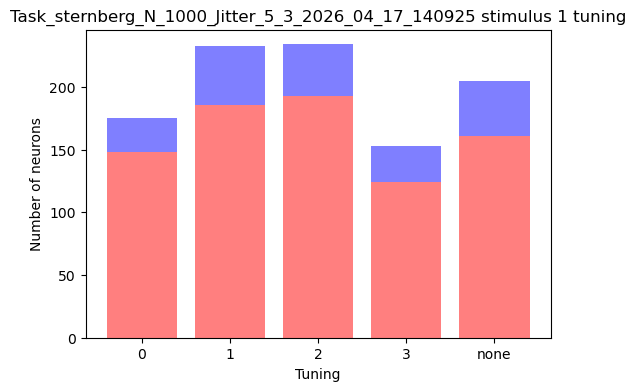

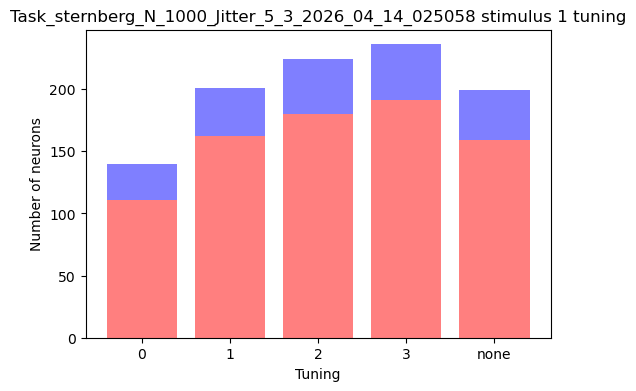

In [6]:
importlib.reload(rn)

for i, model_name in enumerate(model_names):
    
    model_dir = os.path.join(all_models_dir, model_name)
    save_path = os.path.join(model_dir, 'stim1_tuning_nonparametric.npz')
    if os.path.exists(save_path):
        print(f'Tuning file already exists for {model_name}, skipping...')
        continue
    
    # neural data
    _, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                                all_models_dir = all_models_dir, load_LFP=False)
    _, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                                all_models_dir = all_models_dir, load_LFP=False)
    rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0) # concatenate
    
    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    # behavioral data
    trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_match",
                                                        all_models_dir=all_models_dir)
    trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_stim",
                                                        all_models_dir=all_models_dir)
    trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
    trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
    trial_outputs = np.concatenate((trial_outputs_match, trial_outputs_stim), axis=0)

    # turn all inf into nans
    trial_labels = np.nan_to_num(trial_labels, nan=np.inf)
    trial_perfs = np.nan_to_num(trial_perfs, nan=np.inf)
    trial_outputs = np.nan_to_num(trial_outputs, nan=np.inf)
    
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    bhv_vars = {'trial_labels': trial_labels, 'trial_perfs': trial_perfs, 'trial_outputs': trial_outputs}
    tuning = rn.calc_stim1_tuning_nonparametric(model_name, condn_phrase, condn_num, other_labels = "balance_match",
                        rates_data=rates_data, other_variables=bhv_vars,
                        kw_alpha=0.05, dunn_alpha=0.05, dunn_p_adjust='holm',
                        use_prescreen=True, prescreen_alpha=0.20,
                        show_progress=True, all_models_dir=all_models_dir)

    rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} stimulus 1 tuning', ax=None)

    # save tuning to the model folder as stim1_tuning.npz
    np.savez(save_path, stim1_tuning=tuning)

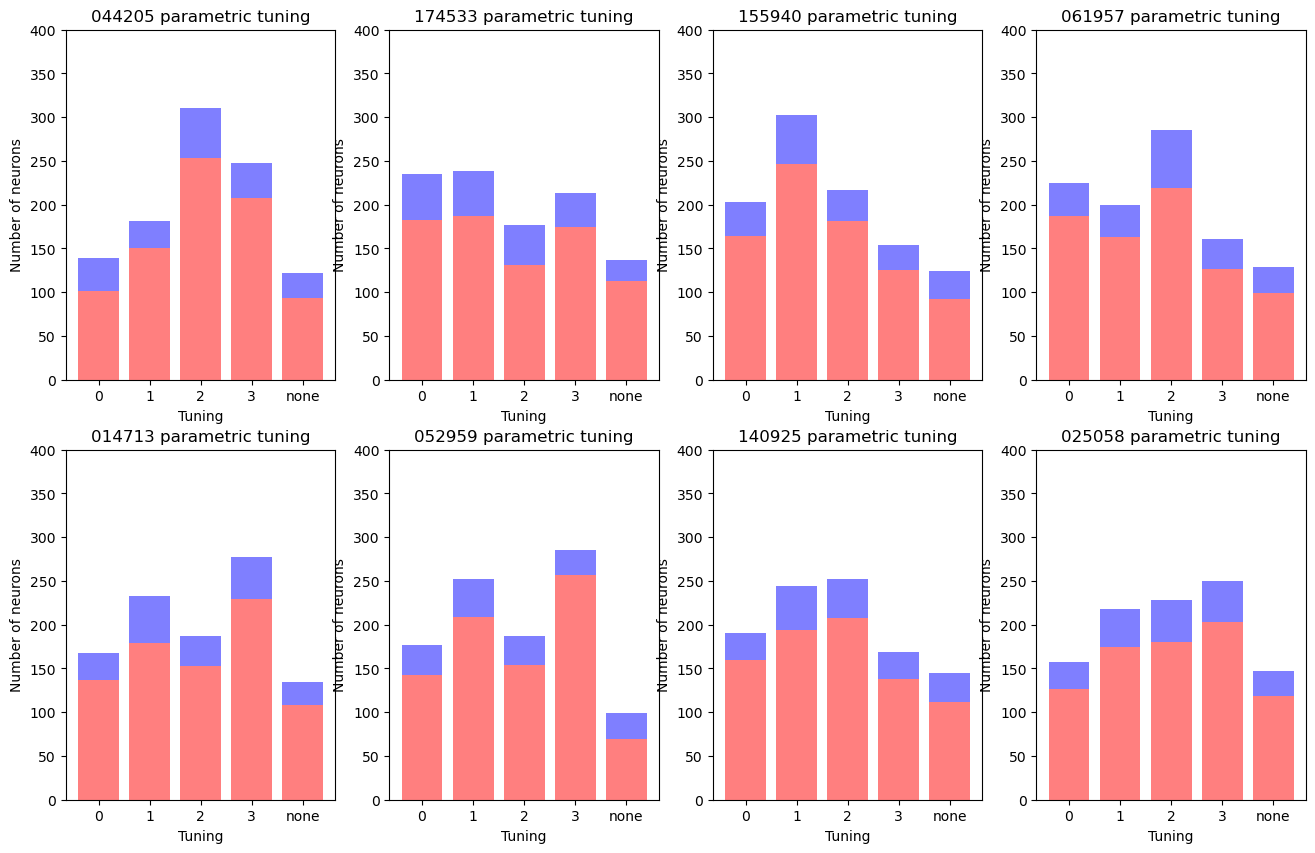

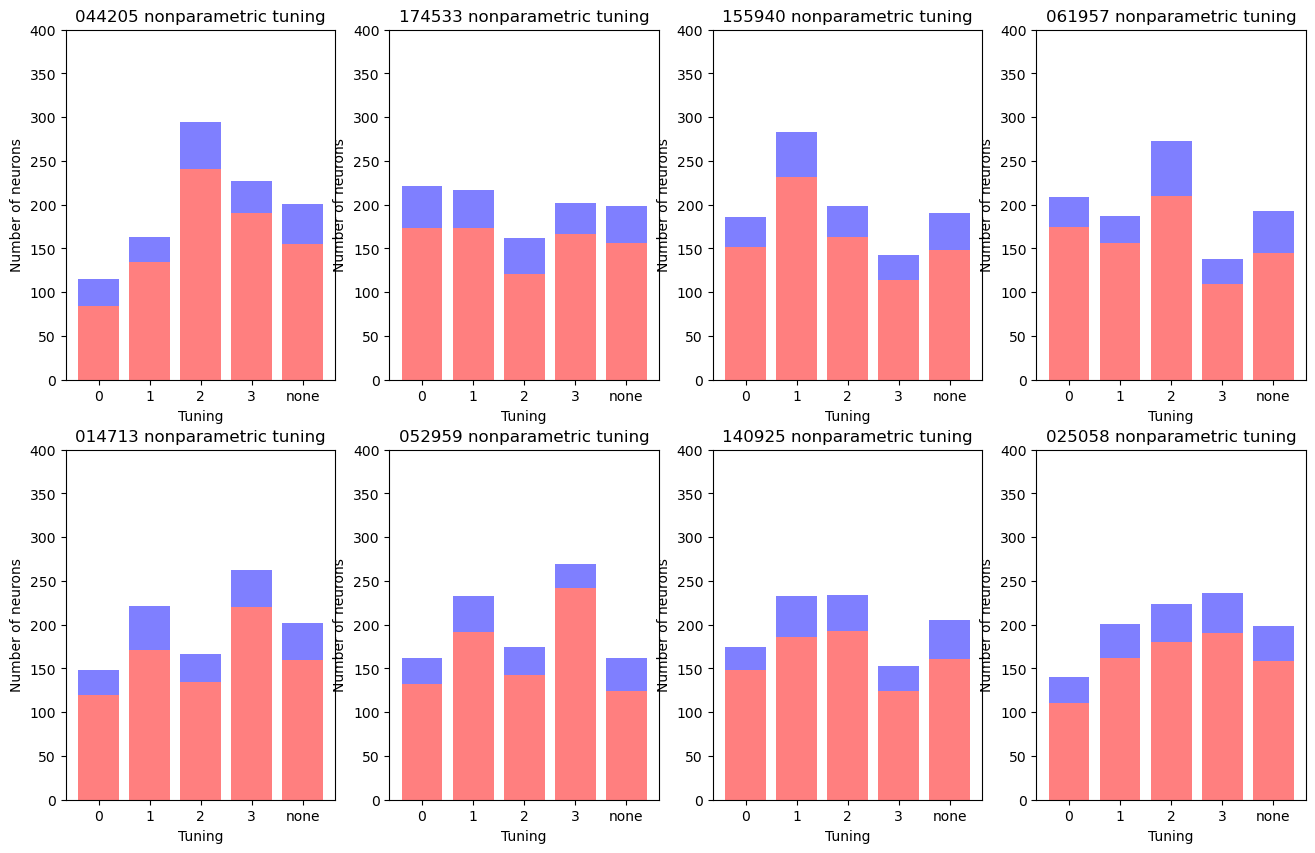

In [11]:
# make single plot of all parametric, and all nonparametric. subplot for each model

tuning_names = ['stim1_tuning.npz', 'stim1_tuning_nonparametric.npz']
label_name = ['parametric', 'nonparametric']

for i, tuning_name in enumerate(tuning_names):
    fig, ax = plt.subplots(2, 4, figsize=(16,10))
    ax = ax.flatten()
    for j, model_name in enumerate(model_names):
        model_dir = os.path.join(all_models_dir, model_name)
        save_path = os.path.join(model_dir, tuning_name)
        tuning = np.load(save_path)['stim1_tuning']
        exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
        
        rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name[-6:]} {label_name[i]} tuning', ax=ax[j])
        ax[j].set_ylim([0, 400])
        
plt.show()
    

### more firing rate plots

(536, 1000, 450)


/tmp/ipykernel_670314/2763188539.py:44: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_670314/2763188539.py:45: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


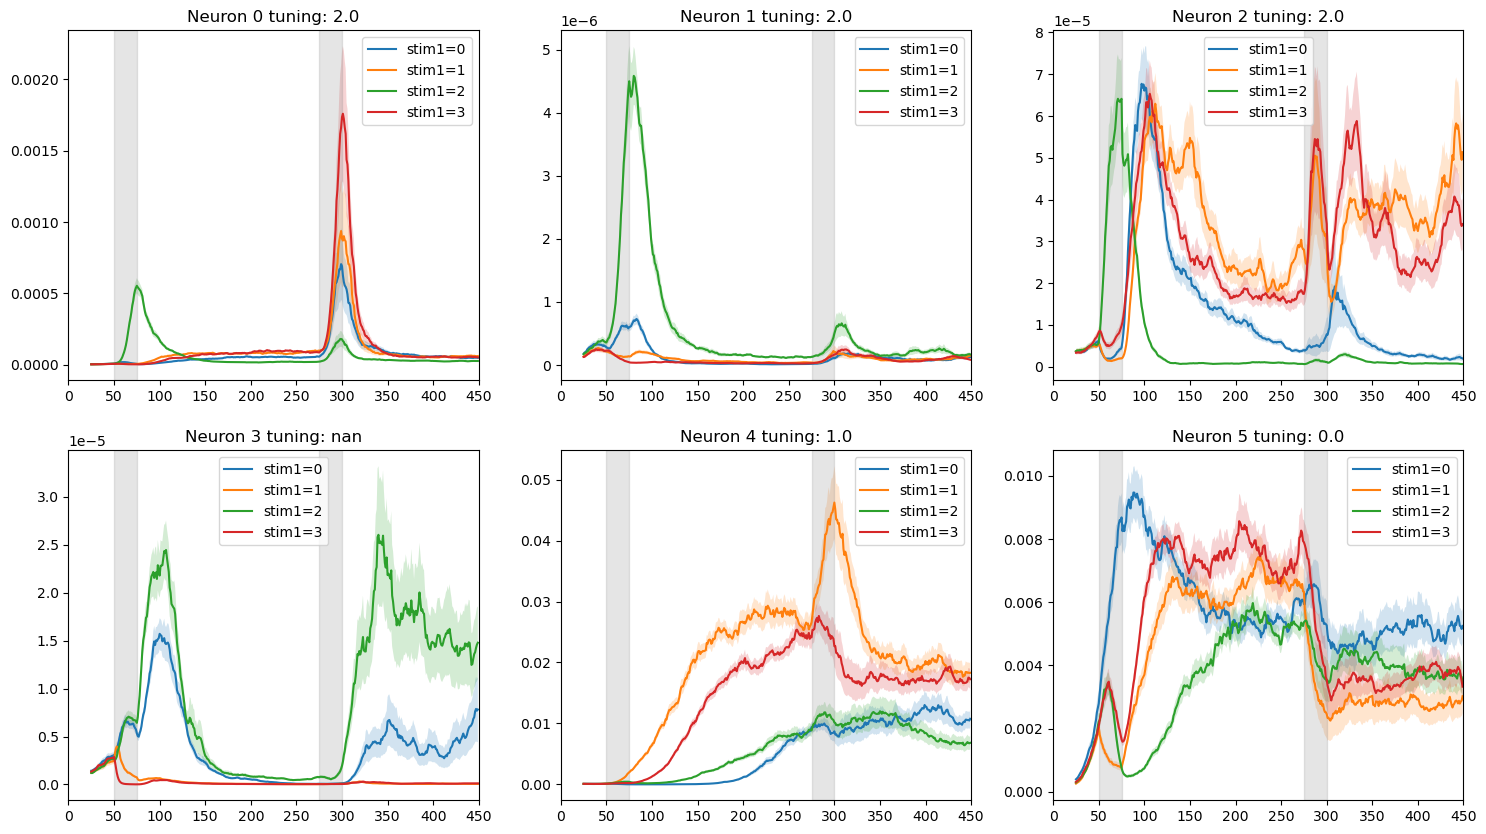

In [13]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={stim1_identity}')
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_670314/2698652144.py:52: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_670314/2698652144.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


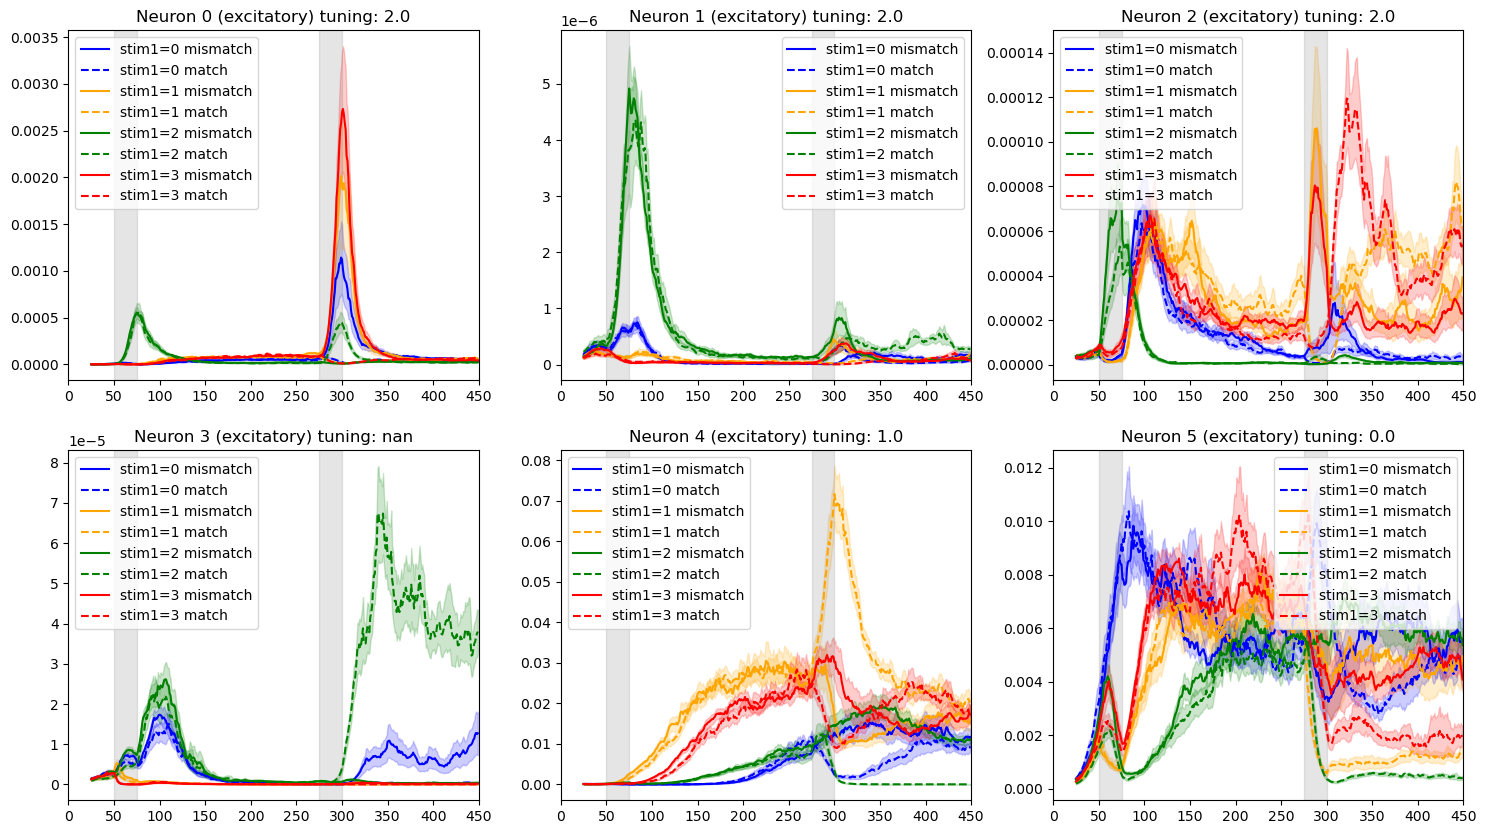

In [15]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inhibitory", "excitatory"][is_exc]}) tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_670314/3415807020.py:52: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_670314/3415807020.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


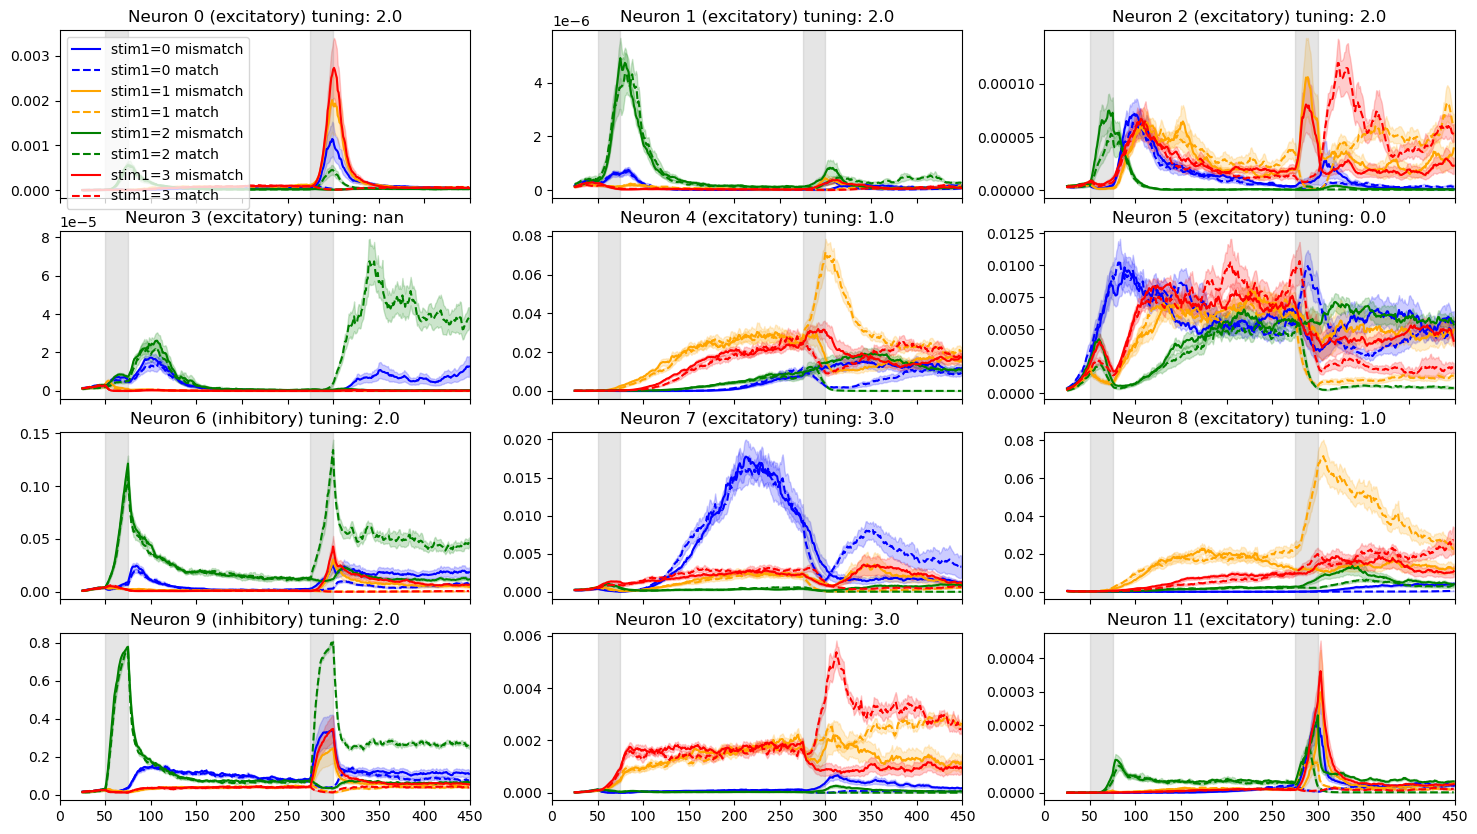

In [19]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(12):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inhibitory", "excitatory"][is_exc]}) tuning: {neuron_tuning}')
    if neuron_idx == 0:
        ax.legend()

(536, 1000, 450)


/tmp/ipykernel_670314/121384892.py:52: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_670314/121384892.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


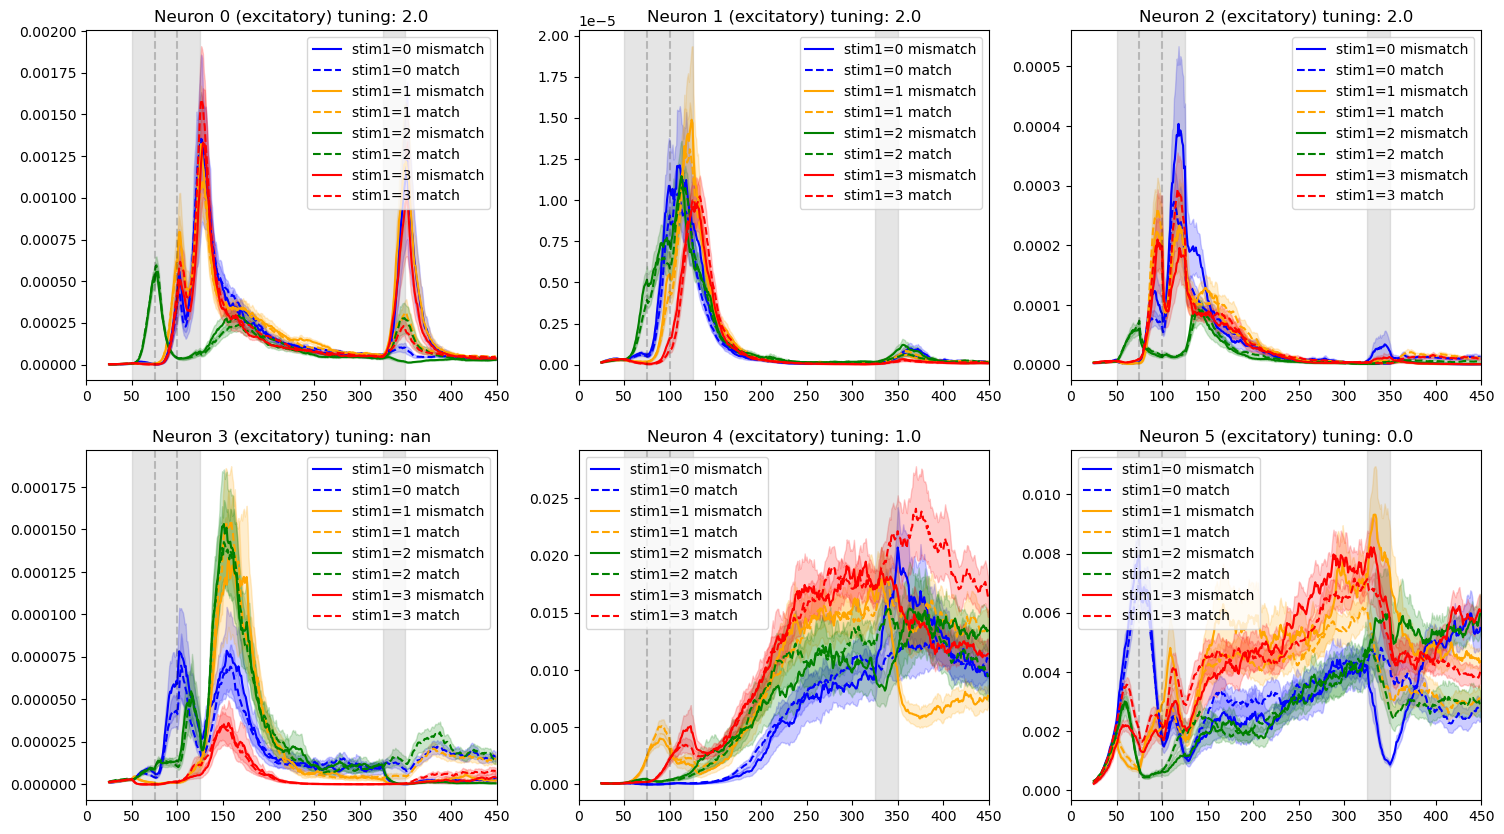

In [23]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 3
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,2]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inhibitory", "excitatory"][is_exc]}) tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_670314/861104562.py:52: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_670314/861104562.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


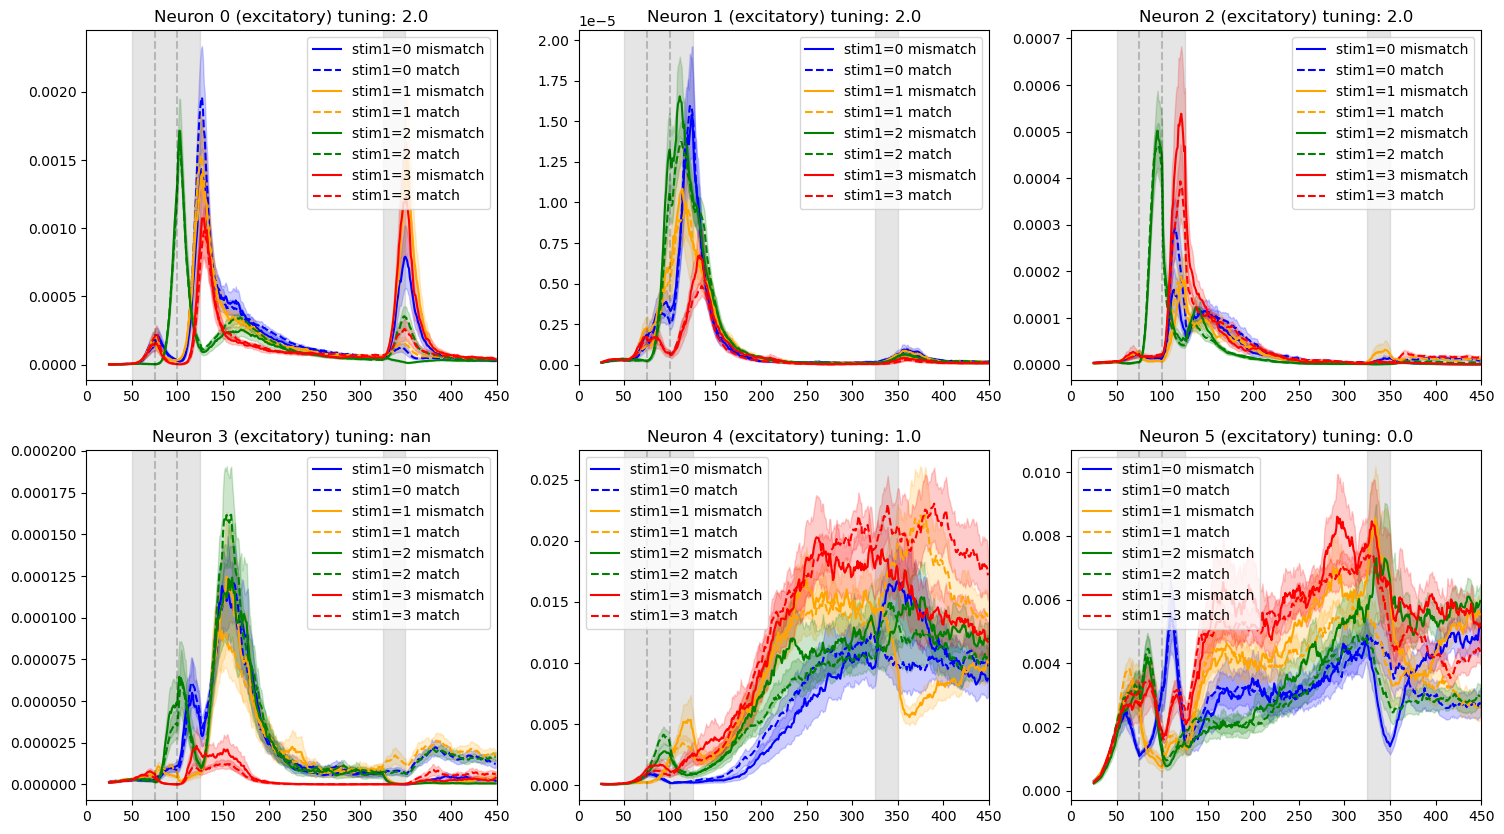

In [24]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 3
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,3]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inhibitory", "excitatory"][is_exc]}) tuning: {neuron_tuning}')
    ax.legend()

(536, 1000, 450)


/tmp/ipykernel_670314/3104419341.py:52: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(match_trial_rate, axis=0)
/tmp/ipykernel_670314/3104419341.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')


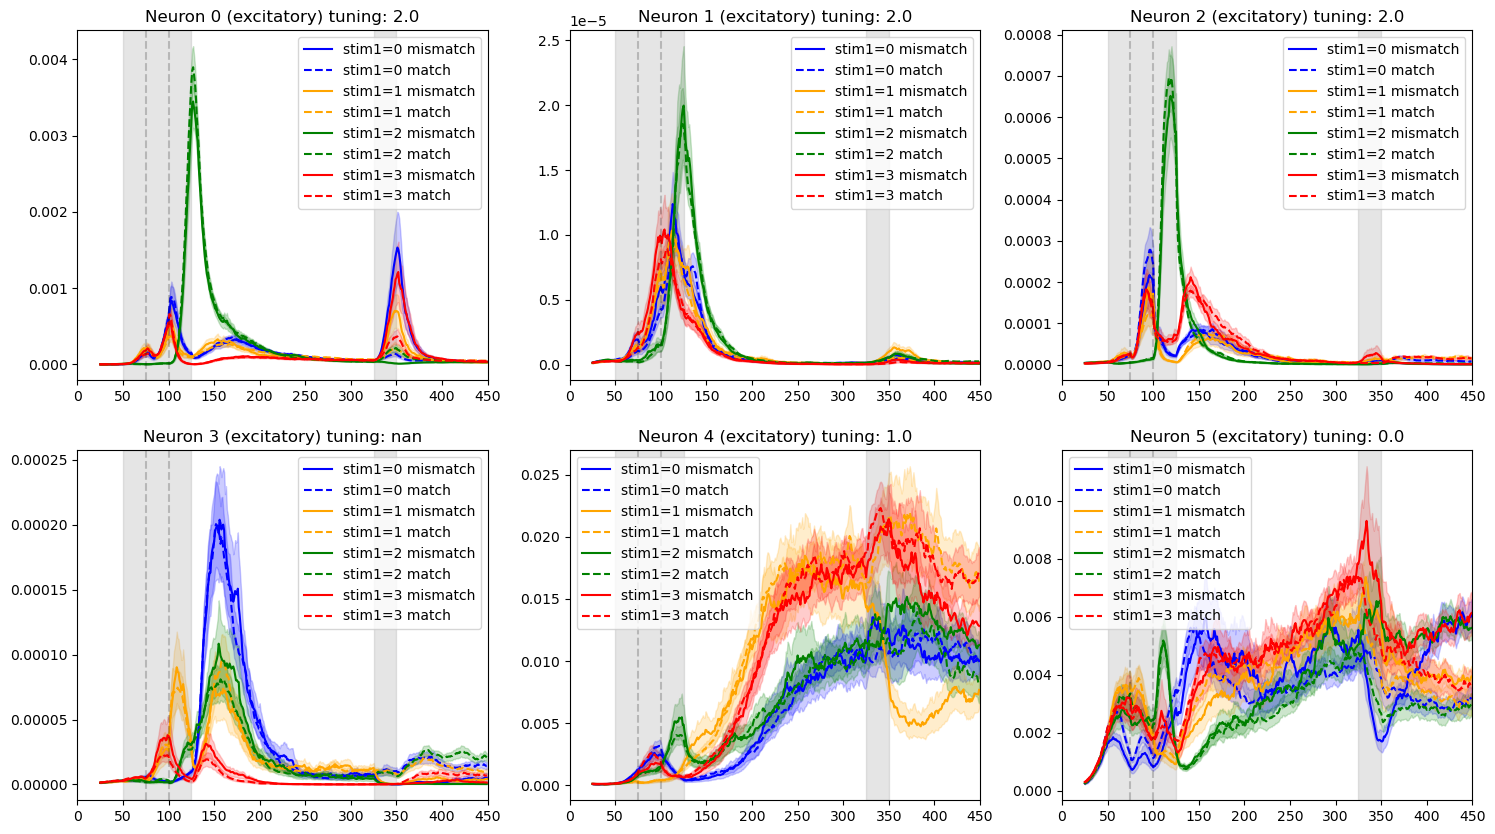

In [25]:
# sanity check -- for one model, plot examples of tuned neurons for stim 1 identity across loads
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[3]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 3
# plot a few examples of tuned neurons
fig, axs = plt.subplots(2, 3, figsize=(18,10))
axs = axs.flatten()
colors = ['b','orange','g','r']
linestyles = ['solid', '--']
for neuron_idx in range(6):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot one load1 trial for each stim identity
    for stim1_identity in range(4):
        trial_type = [load, stim1_identity]
        trial_idxs = np.where(np.all(trial_labels[:,[0,4]] == trial_type, axis=1))[0]
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        for j, match in enumerate([-1, 1]):  # mismatch = -1, match = 1
            match_idxs = np.where(trial_labels[trial_idxs, 1] == match)[0]
            match_trial_rate = trial_rate[match_idxs]
            mean_rate = np.nanmean(match_trial_rate, axis=0)
            sem_rate = scipy.stats.sem(match_trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'stim1={stim1_identity} {["mismatch","match"][j]}', color = colors[stim1_identity], linestyle=linestyles[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[stim1_identity], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inhibitory", "excitatory"][is_exc]}) tuning: {neuron_tuning}')
    ax.legend()

## Load & Stim selectivity together

### load-selective within stim1-selection

In [5]:
# start with one model

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

load_tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

# build database for each neuron and its tuning
neuron_db = []
for neuron_idx in range(load_tuning.shape[0]):
    neuron_info = {'load_tuning': load_tuning[neuron_idx],
                   'stim1_tuning': stim1_tuning[neuron_idx]}
    neuron_db.append(neuron_info)
    
neuron_db = pd.DataFrame(neuron_db)
neuron_db

,load_tuning,stim1_tuning
0,NaN,3.0
1,3.0,2.0
2,3.0,2.0
3,NaN,1.0
4,3.0,2.0
...,...,...
995,3.0,2.0
996,NaN,1.0
997,3.0,1.0
998,3.0,1.0


In [6]:
neuron_db['tuning_combination'] = neuron_db.apply(lambda row: f"load{row['load_tuning']}_stim{row['stim1_tuning']}", axis=1)
tuning_counts = neuron_db['tuning_combination'].value_counts()
tuning_counts

tuning_combination
load3.0_stim2.0    219
load3.0_stim3.0    113
load3.0_stimnan     96
loadnan_stim3.0     92
loadnan_stimnan     87
loadnan_stim1.0     79
load3.0_stim1.0     65
loadnan_stim2.0     61
load3.0_stim0.0     53
loadnan_stim0.0     52
load1.0_stim3.0     22
load1.0_stim1.0     19
load1.0_stimnan     18
load1.0_stim2.0     14
load1.0_stim0.0     10
Name: count, dtype: int64

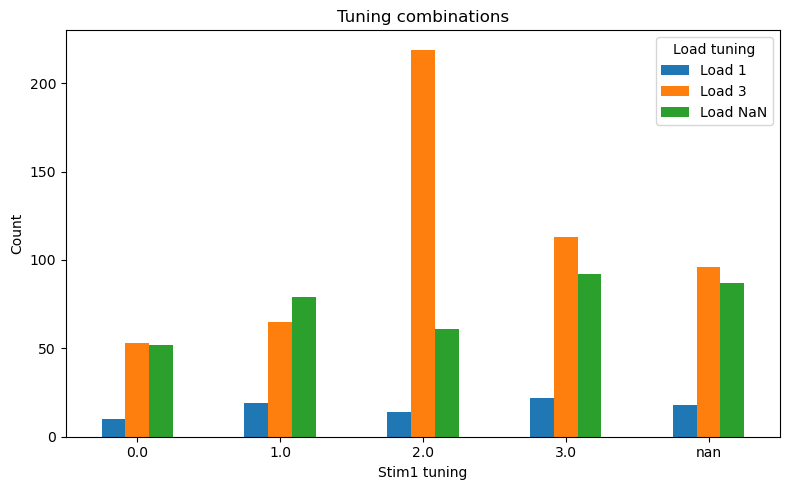

In [12]:
# barplot of count of unique tuning combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Recreate counts as a DataFrame
df_counts = tuning_counts.rename_axis('combination').reset_index(name='count')

# Extract load and stim values from strings
df_counts[['load', 'stim']] = df_counts['combination'].str.extract(r'load(.*?)_stim(.*)')

# Convert to numeric (keep NaN properly)
df_counts['load'] = pd.to_numeric(df_counts['load'], errors='coerce')
df_counts['stim'] = pd.to_numeric(df_counts['stim'], errors='coerce')

# Pivot so rows = stim, columns = load
pivot = df_counts.pivot(index='stim', columns='load', values='count')

# Reindex to enforce order
pivot = pivot.reindex(index=[0,1,2,3,np.nan], columns=[1,3,np.nan])

# Plot
pivot.plot(kind='bar', figsize=(8,5))

plt.xlabel('Stim1 tuning')
plt.ylabel('Count')
plt.title('Tuning combinations')
plt.legend(title='Load tuning', labels=['Load 1', 'Load 3', 'Load NaN'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### old

In [ ]:
# save some tuning

from scipy.io import savemat
import concurrent.futures
importlib.reload(sn)

delays = [50, 150]

def process_model_condn(args):
    model_name, condn_num, condn_phrase, all_models_dir = args
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    untuned_idx = np.where(np.isnan(tuning))[0]

    save_path = os.path.join(all_models_dir, model_name, f'tuning_{condn_phrase}_{condn_num}.mat')
    savemat(save_path, {'tuning': tuning, 'untuned_idx': untuned_idx})

    return f'Saved tuning for {model_name} at {condn_phrase} {condn_num} with {len(untuned_idx)} untuned neurons.'

# Prepare tasks
tasks = []
for model_name in model_dirs:
    for condn_num in delays:
        tasks.append((model_name, condn_num, condn_phrase, all_models_dir))

# Run in parallel
with concurrent.futures.ProcessPoolExecutor() as executor:
    for result in executor.map(process_model_condn, tasks):
        print(result)


Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759 at delay 50 with 14 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759 at delay 150 with 14 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905 at delay 50 with 28 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905 at delay 150 with 29 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403 at delay 50 with 17 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403 at delay 150 with 18 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544 at delay 50 with 17 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544 at delay 150 with 18 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857 at delay 50 with

In [ ]:
n_untuned = np.zeros((len(model_dirs), len(delays)))
for i, model_name in enumerate(model_dirs):
    for j, condn_num in enumerate(delays):
        tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
        n_untuned[i, j] = np.sum(np.isnan(tuning))
    print(f'Number of untuned neurons for {model_name}: {n_untuned[i, :]}')


Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_192759: [14. 14.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_191905: [28. 29.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194403: [17. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_195544: [17. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_185857: [17. 20.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_184512: [34. 34.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_193702: [18. 18.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_162650: [39. 40.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_194942: [29. 30.]
Number of untuned neurons for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_182548: [29. 22.]


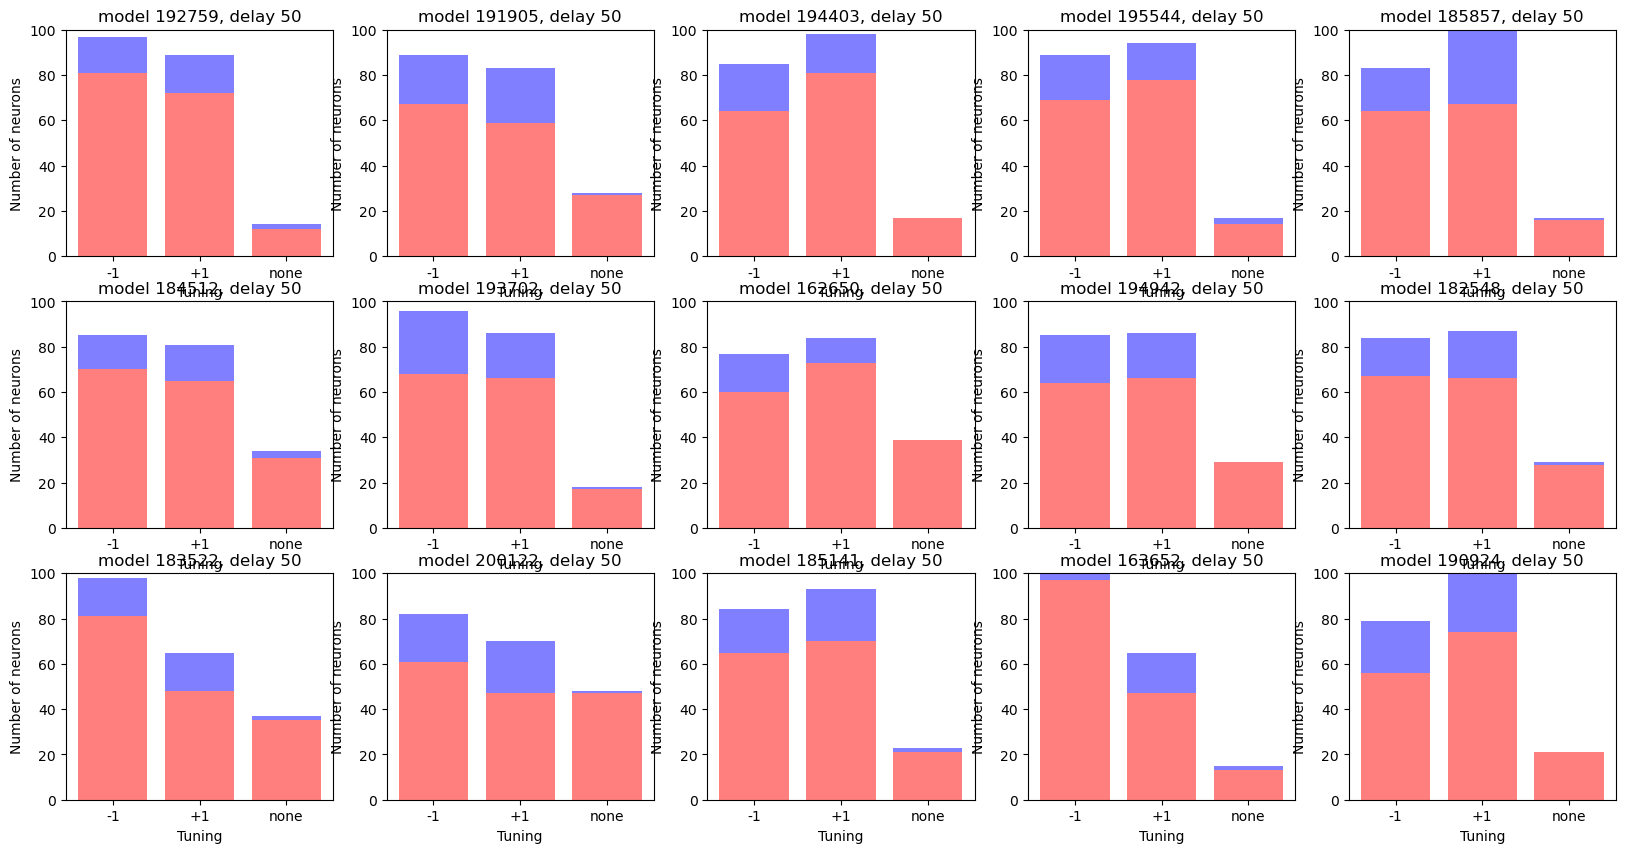

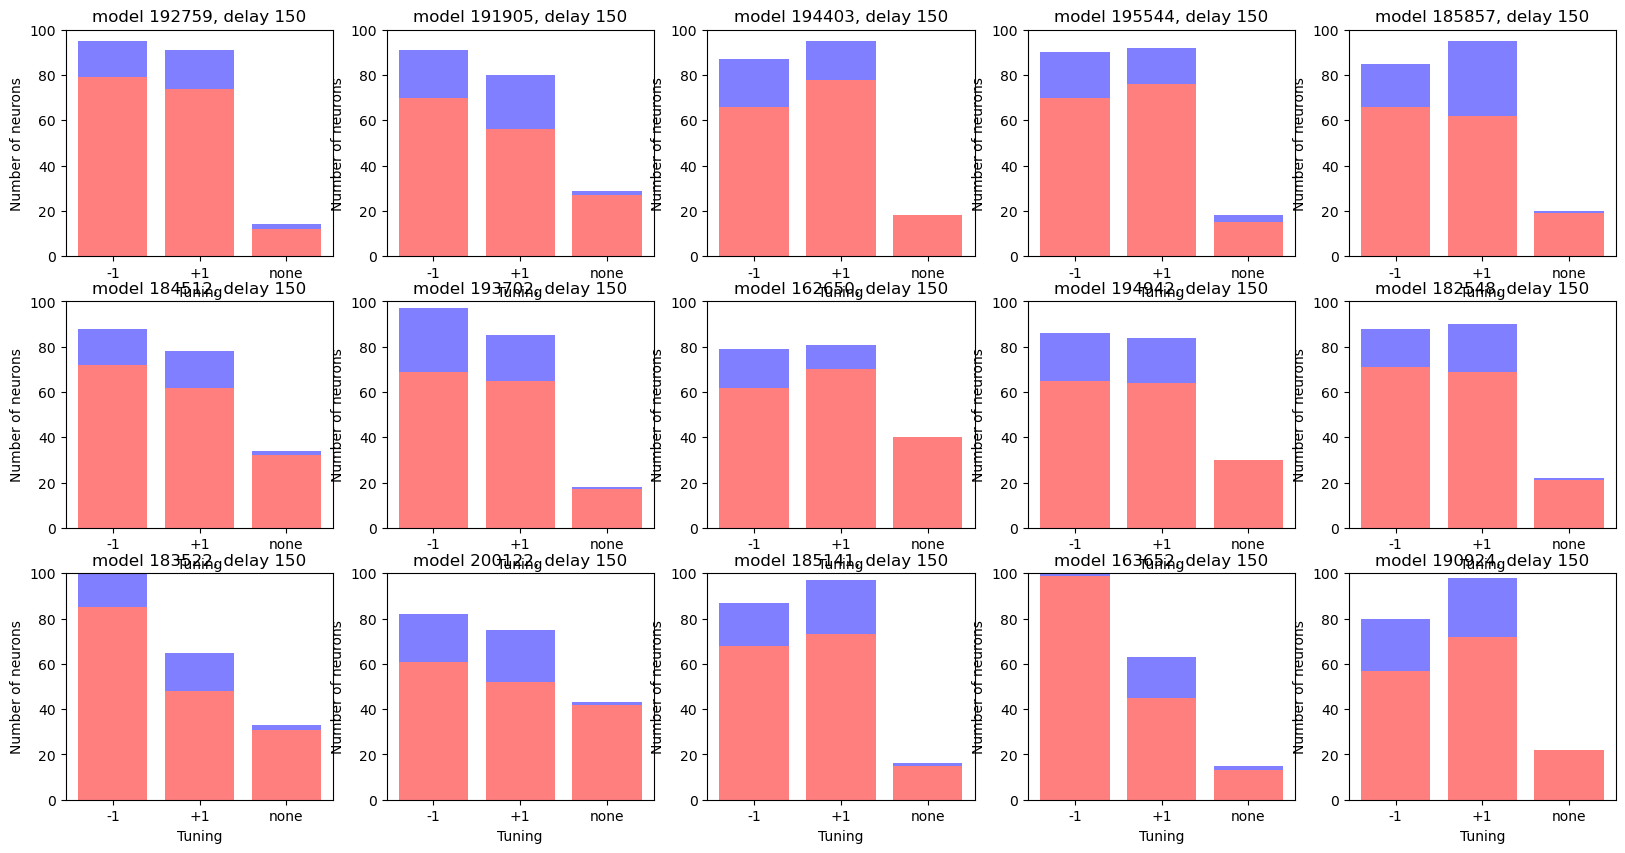

In [ ]:
# plot tuning

for j, condn_num in enumerate(delays):
    fig, axs = plt.subplots(3, 5, figsize=(20, 10))
    axs = axs.flatten()
    for i, model_name in enumerate(model_dirs):
        tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
        exc_ind, inh_ind = ld.get_celltype_label(model_name, condn_phrase=condn_phrase, condn_num=condn_num, all_models_dir=all_models_dir)
        sn.plot_stim1_tuning(tuning, exc_ind=exc_ind, ax=axs[i], title=f'model {model_name[-6:]}, {condn_phrase} {condn_num}')
plt.show()